In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

In [2]:
plt.rc('axes', titlesize='medium')
plt.rc('axes', titlelocation='left')
plt.rc('axes.spines', right=False)
plt.rc('axes.spines', top=False)
sizets = (8,4.5)
plt.rc('figure', figsize=sizets)

# Time series Forecasting

## A tidy forecasting workflow

The process of producing forecasts can be split up into a few fundamental steps.

1. Preparing data
2. Data visualisation
3. Specifying a model
4. Model estimation
5. Accuracy \& performance evaluation
6. Producing forecasts

![Tidy Workflow](img/workflow-1.png)

## Data Preparation

* Prepare the data in the correct format:
    - parse dates
    - identify missing values
    - numerical transformations

Example: `global_economy` $\rightarrow$ compute `GDP_per_capita`


In [3]:
global_economy = pd.read_csv('data/global_economy.csv', parse_dates=['Year'], date_format='%Y')
global_economy['GDP'] = global_economy['GDP']/1e12
global_economy['GDP_per_capita'] = global_economy['GDP']/global_economy['Population']

## Data visualization

Let's plot the data for one country

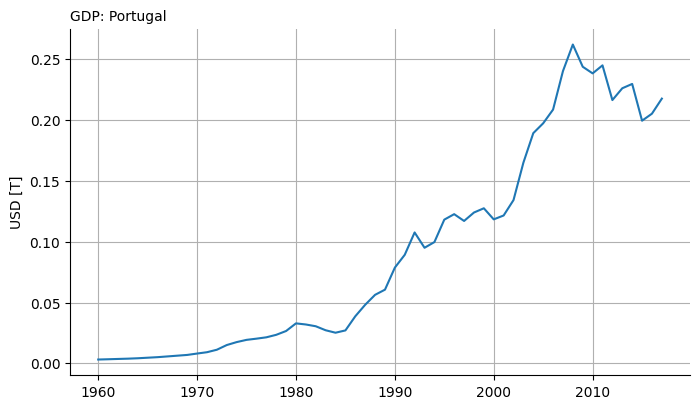

In [4]:
gdppc_pt = global_economy.loc[global_economy['Country']=='Portugal'].set_index('Year', drop=False)
fig, ax = plt.subplots()
ax.plot(gdppc_pt.GDP)
ax.set(ylabel='USD [T]', title='GDP: Portugal')

plt.grid()

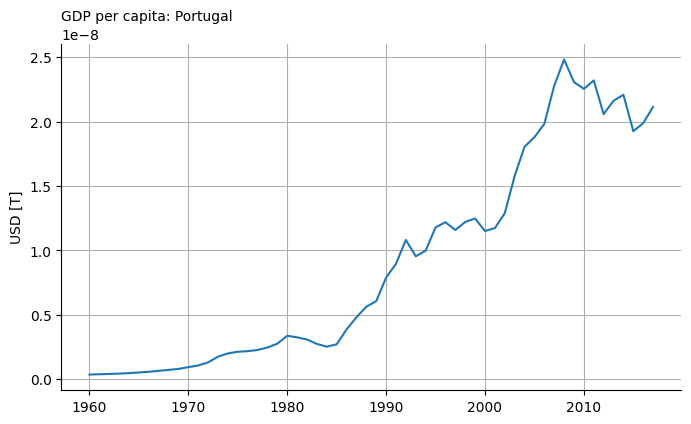

In [5]:
gdppc_pt = global_economy.loc[global_economy['Country']=='Portugal'].set_index('Year', drop=False)
fig, ax = plt.subplots()
ax.plot(gdppc_pt.GDP_per_capita)
ax.set(ylabel='USD [T]', title='GDP per capita: Portugal')

plt.grid()

## Define a model (specify)
* As far as I know, we don't have a python package to select the trend as the model
* Forecasting with trend is simply applying a linear regression

In [6]:
gdppc_pt.head(3)

,Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population,GDP_per_capita
Year,,,,,,,,,,
1960-01-01,Portugal,PRT,1960-01-01,0.003193,NaN,1.182810,19.174692,14.302832,8857716.0,3.604993e-10
1961-01-01,Portugal,PRT,1961-01-01,0.003418,5.534903,1.201132,22.580681,13.471808,8929316.0,3.827299e-10
1962-01-01,Portugal,PRT,1962-01-01,0.003668,6.614448,1.233107,18.963281,15.262101,8993985.0,4.078528e-10


In [7]:
gdppc_pt['Year'] = gdppc_pt['Year'].dt.year
trend_model = smf.ols('GDP ~ Year', gdppc_pt)

In [8]:
print(trend_model.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     439.4
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.47e-28
Time:                        12:07:03   Log-Likelihood:                 123.69
No. Observations:                  58   AIC:                            -243.4
Df Residuals:                      56   BIC:                            -239.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.4519      0.455    -20.760      0.0

In [9]:
results = trend_model.fit()
pred = results.get_prediction(gdppc_pt['Year']).summary_frame()

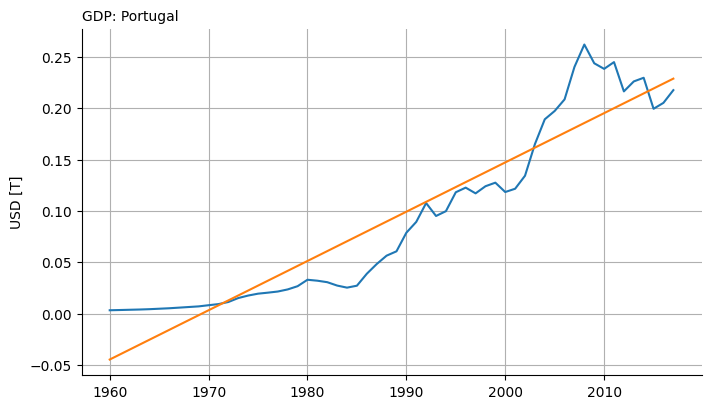

In [10]:
fig, ax = plt.subplots()
ax.plot(gdppc_pt.GDP)
ax.set(ylabel='USD [T]', title='GDP: Portugal')
ax.plot(gdppc_pt.index, pred['mean'])
ax.grid()

In [11]:
global_economy

,Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population,GDP_per_capita
0,Afghanistan,AFG,1960-01-01,0.000538,NaN,NaN,7.024793,4.132233,8996351.0,5.977733e-11
1,Afghanistan,AFG,1961-01-01,0.000549,NaN,NaN,8.097166,4.453443,9166764.0,5.987815e-11
2,Afghanistan,AFG,1962-01-01,0.000547,NaN,NaN,9.349593,4.878051,9345868.0,5.849287e-11
3,Afghanistan,AFG,1963-01-01,0.000751,NaN,NaN,16.863910,9.171601,9533954.0,7.878276e-11
4,Afghanistan,AFG,1964-01-01,0.000800,NaN,NaN,18.055555,8.888893,9731361.0,8.220844e-11
...,...,...,...,...,...,...,...,...,...,...
15145,Zimbabwe,ZWE,2013-01-01,0.019091,1.989493,109.079488,36.668735,21.987759,15054506.0,1.268127e-09
15146,Zimbabwe,ZWE,2014-01-01,0.019496,2.376929,108.847215,33.741470,20.930146,15411675.0,1.264984e-09
15147,Zimbabwe,ZWE,2015-01-01,0.019963,1.779873,106.224541,37.588635,19.160176,15777451.0,1.265294e-09
15148,Zimbabwe,ZWE,2016-01-01,0.020549,0.755869,104.560626,31.275493,19.943532,16150362.0,1.272335e-09


## Generalize to other countries

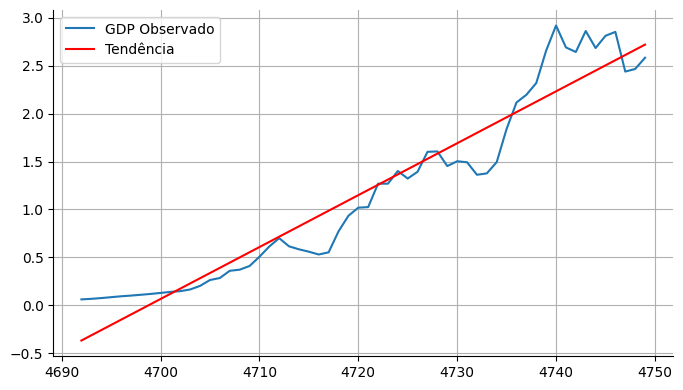

In [12]:
global_economy['Year'] = global_economy['Year'].dt.year
models = (
    global_economy[global_economy['GDP'].notna()]
    .groupby('Country')
    .apply(lambda group: smf.ols('GDP ~ Year', data=group).fit(), include_groups=False)  # Ajusta o modelo para cada grupo
)

# 'France'
country = 'France'
economy = global_economy[global_economy['Country'] == country]

fig, ax = plt.subplots()
ax.plot(economy['GDP'], label='GDP Observado')
m = models[country]
pred = m.get_prediction(economy).summary_frame()

ax.plot(economy.index, pred['mean'], label='Tendência', color='red')

ax.grid()
ax.legend()
plt.show()

In [13]:
gdppc_pt.Year.max()

np.int32(2017)

In [14]:
pred.head(3)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,-0.366413,0.067104,-0.500837,-0.231988,-0.902062,0.169237
1,-0.312276,0.065361,-0.443210,-0.181341,-0.847060,0.222509
2,-0.258139,0.063636,-0.385617,-0.130661,-0.792087,0.275810


## Forecasting

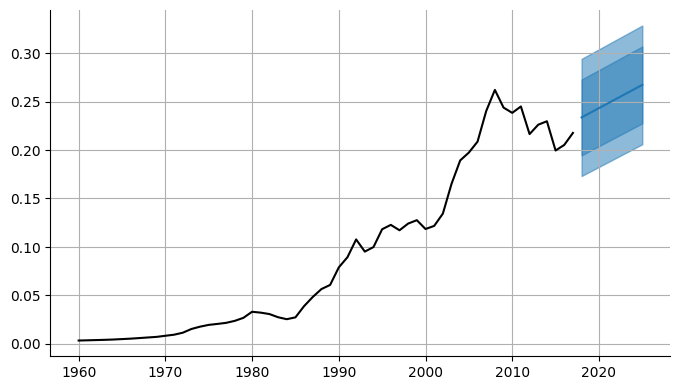

In [15]:
fig, ax = plt.subplots()
ax.plot(gdppc_pt.Year, gdppc_pt.GDP, color='k')
x = pd.DataFrame({'Year': range(2018, 2026)})
pred95 = results.get_prediction(x).summary_frame()
pred80 = results.get_prediction(x).summary_frame(alpha=.2)
ax.plot(x.Year, pred80['mean'])
ax.fill_between(x.Year, pred95.obs_ci_lower, pred95.obs_ci_upper, color='C0', alpha=.5)
ax.fill_between(x.Year, pred80.obs_ci_lower, pred80.obs_ci_upper, color='C0', alpha=.5)
plt.grid()

In [16]:
aus_production = pd.read_csv('data/aus_production.csv')

# Ajuste para converter corretamente a coluna 'Quarter' para 'Date'
aus_production = (
    aus_production
    .assign(
        Date=pd.to_datetime(
            aus_production.Quarter.str.replace(' ', '').str.replace(r'Q(\d)', r'-\1', regex=True),
            format='%Y-%m', errors='coerce'
        )
    )
)
aus_production['Year'] = aus_production['Date'].dt.year
#aus_production.set_index('Date', inplace=True)

In [17]:
aus_production['Quarter'] = aus_production['Date'].dt.quarter

In [18]:
aus_production

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
0,1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1,1,213,5178.0,204.0,532,4436,6,1956-02-01,1956
2,1,227,5297.0,208.0,561,4806,7,1956-03-01,1956
3,2,308,5681.0,197.0,570,4418,6,1956-04-01,1956
4,1,262,5577.0,187.0,529,4339,5,1957-01-01,1957
...,...,...,...,...,...,...,...,...,...
213,1,398,NaN,NaN,2160,57471,238,2009-02-01,2009
214,1,419,NaN,NaN,2325,58394,252,2009-03-01,2009
215,2,488,NaN,NaN,2273,57336,210,2009-04-01,2009
216,1,414,NaN,NaN,1904,58309,205,2010-01-01,2010


## Some simple forecasting methods

### `MEAN(y)`: Average method

  * Forecast of all future values is equal to mean of historical data $\{y_1,\dots,y_T\}$.
  * Forecasts: $\hat{y}_{T+h|T} = \bar{y} = (y_1+\dots+y_T)/T$

In [19]:
!head data/aus_production.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


In [20]:
aus_production = pd.read_csv('data/aus_production.csv')

# Ajuste para converter corretamente a coluna 'Quarter' para 'Date'
aus_production = (
    aus_production
    .assign(
        Date=pd.to_datetime(
            aus_production.Quarter.str.replace(' ', '').str.replace(r'Q(\d)', r'-\1', regex=True),
            format='%Y-%m', errors='coerce'
        )
    )
)
aus_production['Year'] = aus_production['Date'].dt.year
#aus_production.set_index('Date', inplace=True)

In [21]:
aus_production.head()

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
0,1956 Q1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1,1956 Q2,213,5178.0,204.0,532,4436,6,1956-02-01,1956
2,1956 Q3,227,5297.0,208.0,561,4806,7,1956-03-01,1956
3,1956 Q4,308,5681.0,197.0,570,4418,6,1956-04-01,1956
4,1957 Q1,262,5577.0,187.0,529,4339,5,1957-01-01,1957


In [22]:
aus_production['Quarter'] = aus_production['Date'].dt.quarter


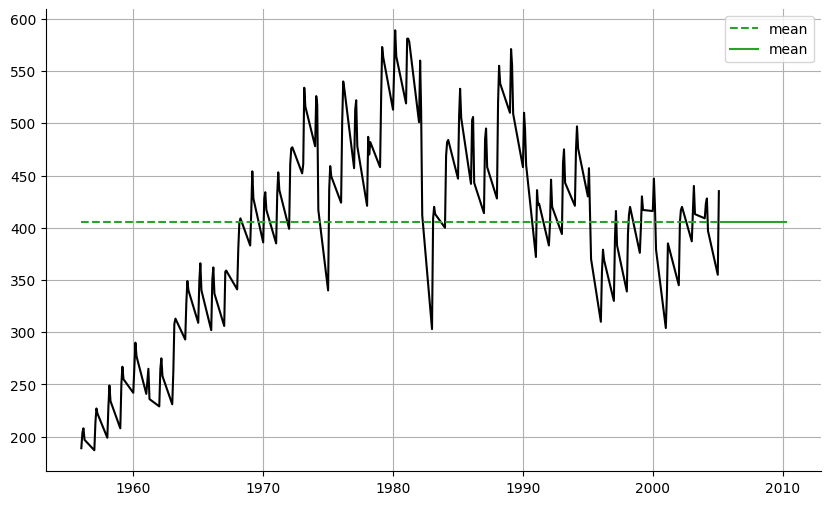

In [23]:
bricks = aus_production[aus_production['Bricks'].notna()].copy()
bricks['average'] = bricks['Bricks'].mean()
bricks.set_index('Date', inplace=True, drop=False)
fc = pd.DataFrame({"Date": pd.date_range(start="2005-01-01", end="2010-03-31", freq="QE")})
fc['average'] = bricks['Bricks'].mean()
fc.set_index('Date', inplace=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bricks.Bricks, color='k')
ax.plot(bricks['average'], color='C2', label='mean', linestyle='--')
ax.plot(fc['average'], color='C2', label='mean', linestyle='-')
ax.legend()
ax.grid()

In [24]:
# gdppc_pt

gdppc_pt.head(3)

,Country,Code,Year,GDP,Growth,CPI,Imports,Exports,Population,GDP_per_capita
Year,,,,,,,,,,
1960-01-01,Portugal,PRT,1960,0.003193,NaN,1.182810,19.174692,14.302832,8857716.0,3.604993e-10
1961-01-01,Portugal,PRT,1961,0.003418,5.534903,1.201132,22.580681,13.471808,8929316.0,3.827299e-10
1962-01-01,Portugal,PRT,1962,0.003668,6.614448,1.233107,18.963281,15.262101,8993985.0,4.078528e-10


In [25]:
fc

,average
Date,
2005-03-31,405.494949
2005-06-30,405.494949
2005-09-30,405.494949
2005-12-31,405.494949
2006-03-31,405.494949
2006-06-30,405.494949
2006-09-30,405.494949
2006-12-31,405.494949
2007-03-31,405.494949


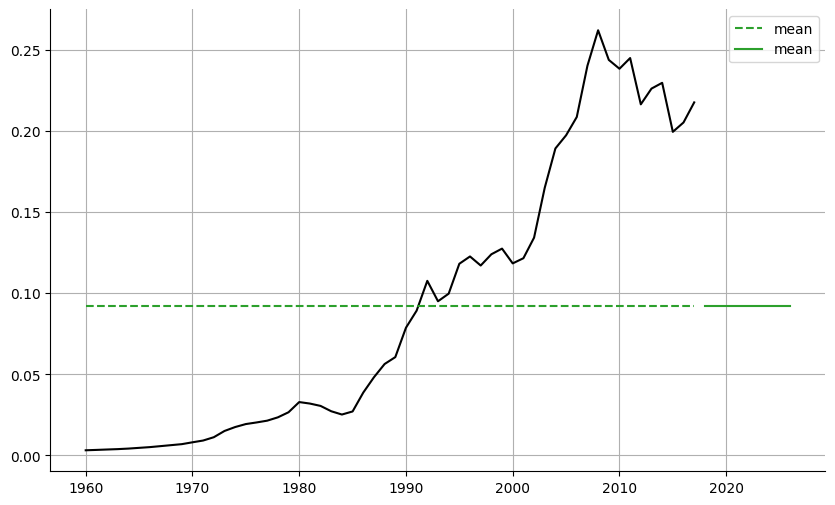

In [26]:
gdp_pt = gdppc_pt[gdppc_pt['GDP'].notna()].copy()
gdp_pt['average'] = gdp_pt['GDP'].mean()
fc = pd.DataFrame({"Date": pd.date_range(start="2017-01-01", end="2026-03-01", freq="YE")})
fc['average'] = gdp_pt['GDP'].mean()
fc.set_index('Date', inplace=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gdp_pt.GDP, color='k')
ax.plot(gdp_pt['average'], color='C2', label='mean', linestyle='--')
ax.plot(fc['average'], color='C2', label='mean', linestyle='-')
ax.legend()
ax.grid()

### `NAIVE(y)`: Naïve method

  * Forecasts equal to last observed value.
  * Forecasts: $\hat{y}_{T+h|T} =y_T$.
  * Consequence of efficient market hypothesis.


In [27]:
gdp_pt.GDP.tail(1).values[0]

np.float64(0.21757108304599)

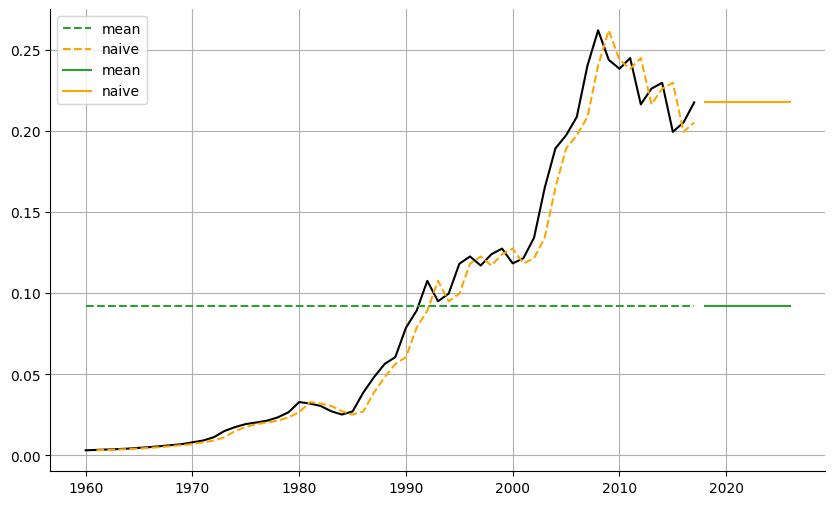

In [28]:
gdp_pt['naive'] = gdp_pt.GDP.shift(1)
fc['naive'] = gdp_pt.GDP.tail(1).values[0]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gdp_pt.GDP, color='k')
ax.plot(gdp_pt['average'], color='C2', label='mean', linestyle='--')
ax.plot(gdp_pt['naive'], color='orange', label='naive', linestyle='--')
ax.plot(fc['average'], color='C2', label='mean', linestyle='-')
ax.plot(fc['naive'], color='orange', label='naive', linestyle='-')
ax.legend()
ax.grid()

## Exercises
1. Produce forecasts for the following series using `mean`, `linear regression` and `naive` methods.
- `aus_production` Beer
- `aus_production` Tobacco
- `aus_production` Gas
2. Plot the forecasts and the historical series.

In [29]:
def compute(df, f):
    """Compute new (or replacement) columns."""
    newdf = pd.DataFrame(f(df), index=df.index)
    dropcols = [col for col in newdf.columns if col in df.columns]
    if dropcols:
        df = df.drop(columns=dropcols)
    return df.join(newdf)


In [30]:
d = pd.read_csv('data/aus_production.csv')
aus_production = (
    d
    .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))
    .pipe(compute, lambda x: dict(Year=x.Date.dt.year))
    .set_index('Date', drop=False)
    #.drop(columns='Date Year'.split())
)


C:\Users\joao.eleuterio\AppData\Local\Temp\ipykernel_29824\1904741557.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  .assign(Date=pd.to_datetime(d.Quarter.str.replace(' ', '')))


In [31]:
aus_production.head(3)

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1956-01-01,1956 Q1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1956-04-01,1956 Q2,213,5178.0,204.0,532,4436,6,1956-04-01,1956
1956-07-01,1956 Q3,227,5297.0,208.0,561,4806,7,1956-07-01,1956


In [32]:
beer = aus_production[['Date', 'Beer']].copy()
beer['days'] = (beer['Date'] - beer['Date'].min()).dt.days
future_dates = pd.date_range(start=beer['Date'].max() + pd.DateOffset(months=3), periods=20, freq='QE')
future_days = (future_dates - beer['Date'].min()).days

fc = pd.DataFrame({'Date': future_dates, 'days': future_days})

# Linear regression
lr = smf.ols('Beer ~ days', beer)


In [33]:
results = lr.fit()
pred = results.get_prediction(beer['days']).summary_frame()
beer['linear_regression'] = pred['mean']
forecasts = results.get_prediction(fc['days']).summary_frame()
fc['linear_regression'] = forecasts['mean']

In [34]:
beer['average'] = beer['Beer'].mean()
fc['average'] = beer['Beer'].mean()

In [35]:
beer['naive'] = beer['Beer'].shift(1)
fc['naive'] = beer['Beer'].iloc[-1]

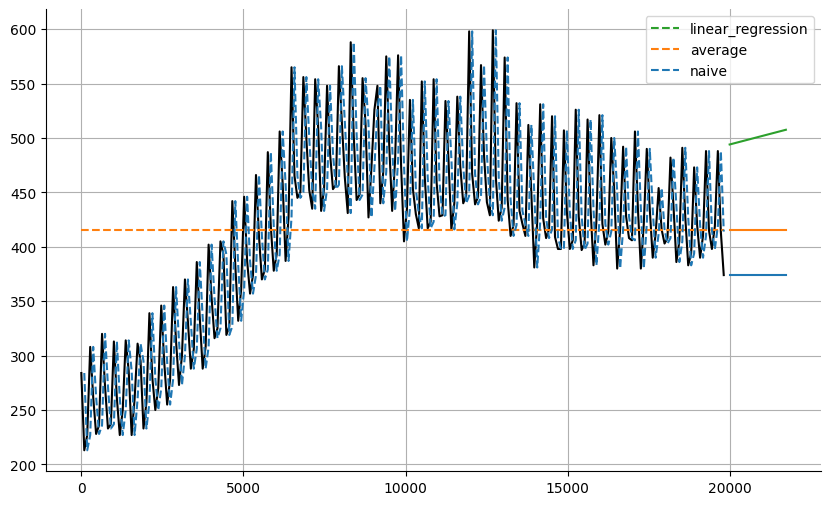

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beer.days, beer.Beer, color='k')
ax.plot(beer.days, beer['linear_regression'], color='C2', label='linear_regression', linestyle='--')
ax.plot(fc.days, fc['linear_regression'], color='C2', linestyle='-')
ax.plot(beer.days, beer['average'], color='C1', label='average', linestyle='--')
ax.plot(fc.days, fc['average'], color='C1', linestyle='-')
ax.plot(beer.days, beer['naive'], color='C0', label='naive', linestyle='--')
ax.plot(fc.days, fc['naive'], color='C0', linestyle='-')

#ax.plot(gdp_pt['naive'], color='orange', label='naive', linestyle='--')
#ax.plot(fc['average'], color='C2', label='mean', linestyle='-')
#ax.plot(fc['naive'], color='orange', label='naive', linestyle='-')
ax.legend()
ax.grid()

### `SNAIVE(y ~ lag(m))`: Seasonal naïve method

  * Forecasts equal to last value from same season.
  * Forecasts: $\hat{y}_{T+h|T} =y_{T+h-m(k+1)}$, where $m=$ seasonal period and $k$ is the integer part of $(h-1)/m$.


In [37]:
from statsforecast.models import SeasonalNaive
from statsforecast import StatsForecast

c:\Users\joao.eleuterio\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
df = beer[['Date', 'Beer']].copy()
df.columns = ['ds', 'y']
df['unique_id'] = 'beer'
sf = StatsForecast(models=[SeasonalNaive(season_length=12)], freq='ME')
fc['s_naive'] = sf.forecast(df=df, h=20)['SeasonalNaive']

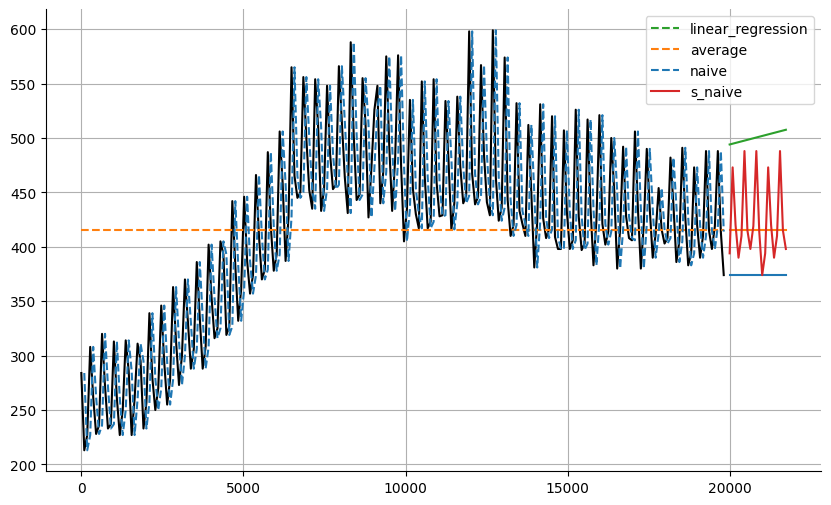

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(beer.days, beer.Beer, color='k')
ax.plot(beer.days, beer['linear_regression'], color='C2', label='linear_regression', linestyle='--')
ax.plot(fc.days, fc['linear_regression'], color='C2', linestyle='-')
ax.plot(beer.days, beer['average'], color='C1', label='average', linestyle='--')
ax.plot(fc.days, fc['average'], color='C1', linestyle='-')
ax.plot(beer.days, beer['naive'], color='C0', label='naive', linestyle='--')
ax.plot(fc.days, fc['naive'], color='C0', linestyle='-')
ax.plot(fc.days, fc['s_naive'], color='C3', label='s_naive', linestyle='-')

#ax.plot(gdp_pt['naive'], color='orange', label='naive', linestyle='--')
#ax.plot(fc['average'], color='C2', label='mean', linestyle='-')
#ax.plot(fc['naive'], color='orange', label='naive', linestyle='-')
ax.legend()
ax.grid()

Seasonal Naive with GDP data = Naive

In [40]:
gdp_pt.index = pd.to_datetime(gdp_pt.index)
df = gdp_pt[['GDP']].copy().reset_index()
df.columns = ['ds', 'y']
df['unique_id'] = 'gdp_pt'

sf = StatsForecast(models=[SeasonalNaive(season_length=1)], freq='YE')
fc['s_naive'] = sf.forecast(df=df, h=8)['SeasonalNaive']

### `RW(y ~ drift())`: Drift method

 * Forecasts equal to last value plus average change.
 * Forecasts:
 \begin{align*}
 \hat{y}_{T+h|T} & =  y_{T} + \frac{h}{T-1}\sum_{t=2}^T (y_t-y_{t-1})\\
                 & = y_T + \frac{h}{T-1}(y_T -y_1).
 \end{align*}
   * Equivalent to extrapolating a line drawn between first and last observations.


In [42]:
class SimpleTSModel:
    """Simple TS model base class."""
    def __init__(self, y):
        """Determine y data and sampling frequency."""
        if not hasattr(y, 'index'):
            y = pd.Series(y)
        if hasattr(y.index, 'inferred_freq'):
            self.y = y.asfreq(y.index.inferred_freq)
            self.freq = self.y.index.freq
        else:
            self.y = y.copy()
            self.freq = None

    def fit(self):
        """Nothing to do here, but in other libraries this is a method that does things."""
        return self

    def forecast(self, dt=None, end=None, periods=None):
        """Make a forward-looking prediction."""
        assert sum([dt is None, end is None, periods is None]) == 2
        tmax = self.y.index.max()
        if dt is not None:
            end = tmax + (pd.to_timedelta(dt) if self.freq else dt)
        elif end is not None:
            end = pd.to_datetime(end) if self.freq else end
        elif periods is not None:
            end = tmax + periods * (self.freq or 1)
        return self.predict(tmax + 1 * (self.freq or 1), end)

    def _normalize_times(self, start, end):
        """Do some tedious datetime manipulation."""
        Y = self.y
        t0 = Y.index.min()
        if start is None:
            start = t0
        if end is None:
            end = Y.index.max()
        if self.freq is not None:
            start = pd.to_datetime(start)
            end = pd.to_datetime(end)
        if self.freq:
            index = pd.date_range(t0, end, freq=self.freq)
        else:
            index = np.arange(t0, end+1)
        return start, end, index

class TSMean(SimpleTSModel):
    """The future will look like the average of the past."""
    def predict(self, start=None, end=None):
        # value is always the mean
        Y = self.y
        start, end, index = self._normalize_times(start, end)
        m = Y.mean()
        out = pd.Series(m, index=index)
        out = out.loc[start:].copy()
        return out

class TSNaive(SimpleTSModel):
    """Tomorrow will look like today."""
    def predict(self, start=None, end=None):
        # tomorrow probably same as today
        Y = self.y
        start, end, index = self._normalize_times(start, end)
        out = pd.Series(np.nan, index=index)
        out.loc[:Y.index.max()] = Y
        out = out.shift(1)
        out.loc[Y.index.max():] = Y.iloc[-1]
        out = out.loc[start:].copy()
        return out.copy()

class TSNaiveSeasonal(SimpleTSModel):
    """Next year will fluctuate the same way as this year."""
    def __init__(self, y, lag):
        super(TSNaiveSeasonal, self).__init__(y)
        self.lag = lag
        assert self.y.index.min() + lag * (self.freq or 1) < self.y.index.max(), \
            'lag must be less than input timeseries'

    def predict(self, start=None, end=None):
        # tomorrow probably same as this time last year/month/whatever
        Y, lag = self.y, self.lag
        start, end, index = self._normalize_times(start, end)
        out = pd.Series(np.nan, index=index)
        out.loc[:Y.index.max()] = Y
        out = out.shift(lag)
        i = 0
        while np.isnan(out.iloc[-1]):
            mask = out.isna()
            out[mask] = out.shift(lag)[mask]
            i += 1
        out = out.loc[start:].copy()
        return out.copy()

class TSDrift(SimpleTSModel):
    """Draw a line from t=0 thru today, and extrapolate to tomorrow."""
    def predict(self, start=None, end=None):
        # value extrapolated based on slope wrt first observation
        # TODO: might be slightly wrong
        # doesn't *quite* agree with R's RW(Y~drift()) ?
        Y = self.y
        Y0 = Y.values[0]
        YT = Y.shift(-1)
        start, end, index = self._normalize_times(start, end)
        YT = pd.Series(np.nan, index=index)
        YT.loc[Y.index.min():Y.index.max()] = Y
        YT = YT.shift(1)
        YT.iloc[0] = Y.iloc[0]
        h = pd.Series(1, index=index)
        extrap_mask = YT.isna()
        h.loc[YT.isna()] = np.arange(1, extrap_mask.sum()+1)
        YT.loc[extrap_mask] = Y.iloc[-1]
        x = np.maximum(1, np.arange(len(YT)) - 1)
        out = YT + h * ((YT - Y0) / x)
        out.iloc[0] = np.nan
        out = out.loc[start:].copy()
        return out.copy()

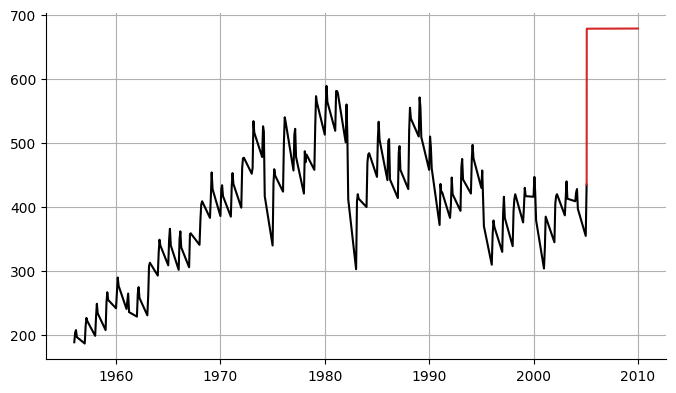

In [43]:
dr = TSDrift(bricks.Bricks)
fig, ax = plt.subplots()
ax.plot(bricks.Bricks, color='k')
ax.plot(dr.forecast(end='2010'), color='C3', label='drift')
ax.grid()


## Fitted values
* How well the method fits the data
* How well the method forecasts

* $\hat{y}_{t|t-1}$ is the forecast of $y_t$ based on observations $y_{1},\dots,y_{t-1}$
* We call these "fitted values"
* Sometimes drop the subscript: $\hat{y}_{t} = \hat{y}_{t|t-1}$
* $\hat{y}_{t} = \overline{y}_t$ for average method
* $\hat{y}_{t} = y_{t-1} + (y_t - y_1)/(T-1)$ for drift method

## Residuals

* difference between observed value and its fitted value
* Assumptions:
    * $\{e_t\}$ uncorrelated. If they aren't, then information left in residuals that should be used in computing forecasts
    * $\{e_t\}$ have mean zero. If they don't, then forecasts are biased
* Useful properties (for distributions & prediction intervals
    * $\{e_t\}$ have constant variance
    * $\{e_t\}$ are normally distributed

In [44]:
GOOG = (
    pd.read_csv('data/gafa_stock.csv')
    .query("Symbol == 'GOOG'")
    .sort_values('Date')
    .reset_index(drop=True)
    .pipe(compute, lambda x: dict(Date = pd.to_datetime(x.Date, format='%Y-%m-%d')))
)

In [45]:
GOOG.dtypes

Symbol               object
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
Date         datetime64[ns]
dtype: object

In [46]:
GOOG_2015 = GOOG.query('Date.dt.year == 2015')

In [47]:
len(GOOG_2015)

252

In [48]:
Y = GOOG.Close
Ytrain = GOOG_2015.Close
nsamples = len(GOOG_2015)
m = TSMean(Ytrain)
n = TSNaive(Ytrain).fit()
s = TSNaiveSeasonal(Ytrain, nsamples - 2)
dr = TSDrift(Ytrain)

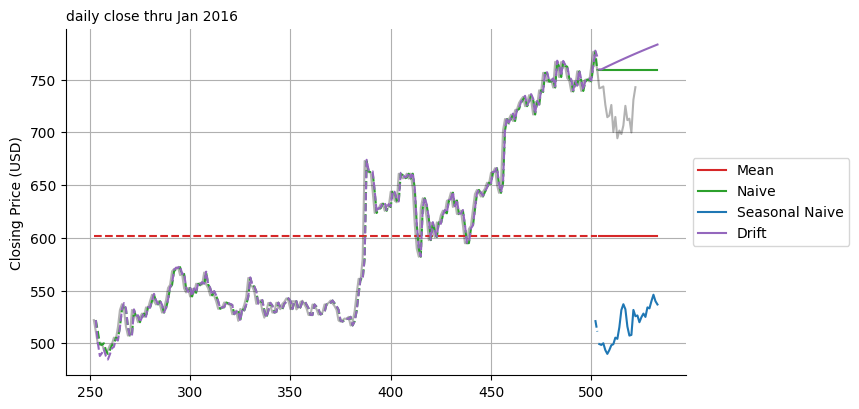

In [49]:
fig, ax = plt.subplots()
ax.plot(Y[GOOG.Date.between('2015-01-01', '2016-01-30')], color='k', alpha=0.3)
c = 'C3 C2 C0 C4'.split()
ax.plot(m.predict(),  ls='--', color=c[0])
ax.plot(n.predict(),  ls='--', color=c[1])
ax.plot(s.predict(),  ls='--', color=c[2])
ax.plot(dr.predict(), ls='--', color=c[3])
ax.plot(m.forecast(30),  color=c[0], label='Mean')
ax.plot(n.forecast(30),  color=c[1], label='Naive')
ax.plot(s.forecast(30),  color=c[2], label='Seasonal Naive')
ax.plot(dr.forecast(30), color=c[3], label='Drift')
ax.set(ylabel='Closing Price (USD)', title='Google stock')
ax.legend(loc='center left', bbox_to_anchor=[1, .5])
ax.set(title='daily close thru Jan 2016')
ax.grid()

In [50]:
results = GOOG_2015.assign(
    mean=m.predict(),
    naive=n.predict(),
    naive_seasonal=s.predict(),
    drift=dr.predict(),
    resid_mean=m.predict() - Ytrain,
    resid_naive=n.predict() - Ytrain,
    resid_naive_seasonal=s.predict() - Ytrain,
    resid_drift=dr.predict() - Ytrain,
)
results.tail(20)


,Symbol,Open,High,Low,Close,Adj_Close,Volume,Date,mean,naive,naive_seasonal,drift,resid_mean,resid_naive,resid_naive_seasonal,resid_drift
484,GOOG,766.010010,768.994995,745.630005,752.539978,752.539978,2590600,2015-12-03,601.550547,762.380005,NaN,763.420881,-150.989431,9.840027,NaN,10.880903
485,GOOG,753.099976,768.489990,750.000000,766.809998,766.809998,2757300,2015-12-04,601.550547,752.539978,NaN,753.533953,-165.259451,-14.270020,NaN,-13.276045
486,GOOG,767.770020,768.729980,755.090027,763.250000,763.250000,1812300,2015-12-07,601.550547,766.809998,NaN,767.860952,-161.699453,3.559998,NaN,4.610952
487,GOOG,757.890015,764.799988,754.200012,762.369995,762.369995,1829500,2015-12-08,601.550547,763.250000,NaN,764.281249,-160.819448,0.880005,NaN,1.911254
488,GOOG,759.169983,764.229980,737.000977,751.609985,751.609985,2700000,2015-12-09,601.550547,762.369995,NaN,763.393111,-150.059438,10.760010,NaN,11.783126
489,GOOG,752.849976,755.849976,743.830017,749.460022,749.460022,1984900,2015-12-10,601.550547,751.609985,NaN,752.583172,-147.909475,2.149963,NaN,3.123150
490,GOOG,741.159973,745.710022,736.750000,738.869995,738.869995,2224400,2015-12-11,601.550547,749.460022,NaN,750.420032,-137.319448,10.590027,NaN,11.550037
491,GOOG,741.789978,748.729980,724.169983,747.770020,747.770020,2412500,2015-12-14,601.550547,738.869995,NaN,739.781475,-146.219473,-8.900025,NaN,-7.988545
492,GOOG,753.000000,758.080017,743.010010,743.400024,743.400024,2666200,2015-12-15,601.550547,747.770020,NaN,748.714925,-141.849477,4.369996,NaN,5.314901
493,GOOG,750.000000,760.590027,739.434998,758.090027,758.090027,1993300,2015-12-16,601.550547,743.400024,NaN,744.322784,-156.539480,-14.690003,NaN,-13.767243


In [51]:
def plot_tsresiduals(Y, y, acf_lags=np.r_[1:26]):
    """Plot timeseries residuals for ground truth Y and estimate y."""
    fig = plt.figure()
    gs = plt.GridSpec(3, 2, figure=fig)
    ts_ax = fig.add_subplot(gs[0, :])
    axs = np.array([ts_ax] + [fig.add_subplot(gs[i, j]) for j in (0, 1) for i in (1, 2)])
    ax, rax, hax, acfax, pacfax = axs
    mask = ~(np.isnan(Y) | np.isnan(y))
    Y, y = Y[mask], y[mask]
    dy = Y - y
    ax.plot(Y, color='k')
    ax.plot(y)
    ax.set(title='Time Series')
    lim = 1.1 * max(-dy.min(), dy.max())
    lim = -lim, lim
    rax.plot(dy)
    rax.set(ylim=lim, title='Residuals')
    sns.histplot(dy, bins=np.linspace(lim[0], lim[1], 22),
             kde=True, stat='density', ax=hax)
    hax.set(title='Residual Distribution')
    sm.graphics.tsa.plot_acf(dy, lags=acf_lags, ax=acfax)
    acfax.set_ylim(-0.5, 0.5)
    sm.graphics.tsa.plot_pacf(dy, lags=acf_lags, ax=pacfax)
    pacfax.set_ylim(-0.5, 0.5)
    for a in axs.ravel():
        a.grid()
    plt.tight_layout()
    return fig, axs


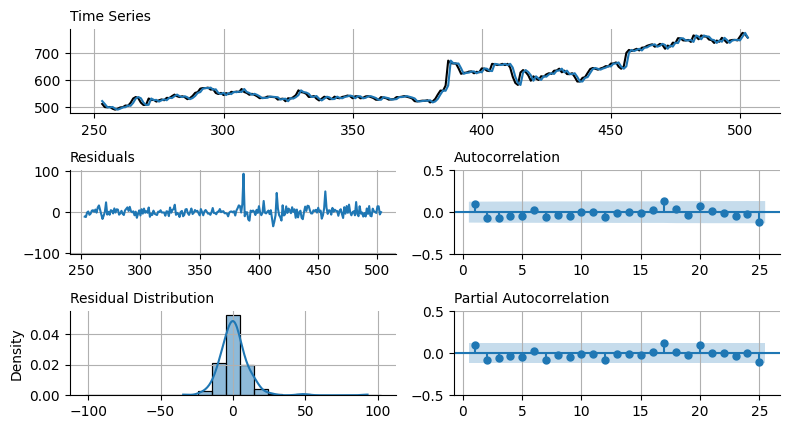

In [52]:
import seaborn as sns
import statsmodels.api as sm
plot_tsresiduals(Ytrain, results.naive)
plt.subplots_adjust(top=.9)

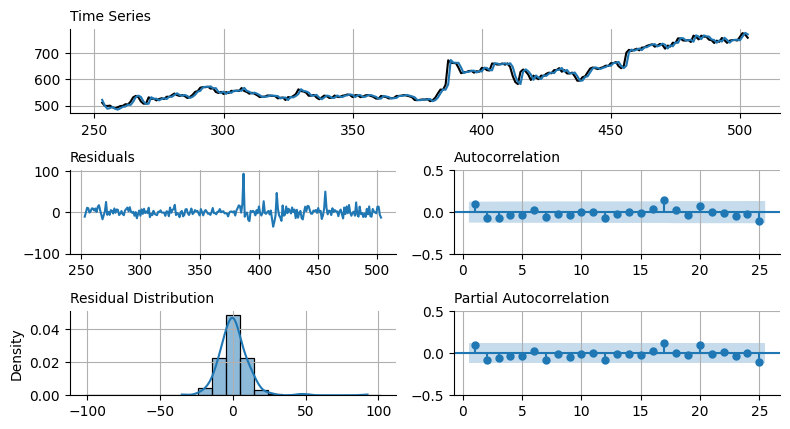

In [53]:
plot_tsresiduals(Ytrain, results.drift)
plt.subplots_adjust(top=.9)

## Forecast Distributions

* All forecasts have an uncertainty
* We express the uncertainty in our forecasts using a probability distribution
* Describes the probability of observing possible future values using the fitted model
* Most time series models produce normally distributed forecasts

## Prediction intervals


In [54]:
from scipy import stats
mult = pd.DataFrame(dict(Percentage=np.r_[50:90:5, 90:100]))
mult['Multiplier'] = stats.norm.isf((1 - mult.Percentage/100) / 2)
mult = mult.set_index('Percentage')
mult

,Multiplier
Percentage,
50,0.674490
55,0.755415
60,0.841621
65,0.934589
70,1.036433
75,1.150349
80,1.281552
85,1.439531
90,1.644854


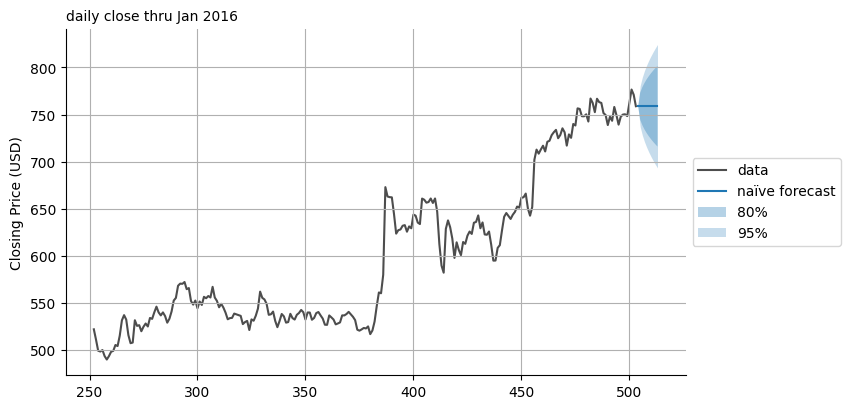

In [55]:
fig, ax = plt.subplots()
g = GOOG[GOOG.Date.lt('2016-02-01')]
ax.plot(GOOG_2015.Close, color='.3', zorder=-10, label='data')
fc = n.forecast(10)
ax.plot(fc, lw=1.5, label='naïve forecast')
sigma = results.resid_naive.std()
m80, m95 = mult.Multiplier.loc[[80, 95]]
didx = fc.index - fc.index.min()
ax.fill_between(fc.index, fc - m80*sigma * np.sqrt(didx), fc + m80*sigma * np.sqrt(didx),
                alpha=.33, lw=0, label='80%')
ax.fill_between(fc.index, fc - m95*sigma * np.sqrt(didx), fc + m95*sigma * np.sqrt(didx),
                alpha=.25, color='C0', lw=0, label='95%')
ax.legend(loc='center left', bbox_to_anchor=[1, .5])
ax.set(title='daily close thru Jan 2016', ylabel='Closing Price (USD)')
ax.grid()

## Forecasting with decomposition

In [56]:
d = pd.read_csv('data/us_employment.csv')
d = us_retail_employment = (
    d
    .assign(date=pd.to_datetime(d.Month, format='%Y %b'))
    .pipe(compute, lambda x: dict(year=x.date.dt.year))
    .query("year >= 1990 and Title == 'Retail Trade'")
    .set_index('date')
    .drop(columns='year Series_ID'.split())
)
us_retail_employment

,Month,Title,Employed
date,,,
1990-01-01,1990 Jan,Retail Trade,13255.8
1990-02-01,1990 Feb,Retail Trade,12966.3
1990-03-01,1990 Mar,Retail Trade,12938.2
1990-04-01,1990 Apr,Retail Trade,13012.3
1990-05-01,1990 May,Retail Trade,13108.3
...,...,...,...
2019-05-01,2019 May,Retail Trade,15691.6
2019-06-01,2019 Jun,Retail Trade,15775.5
2019-07-01,2019 Jul,Retail Trade,15785.9


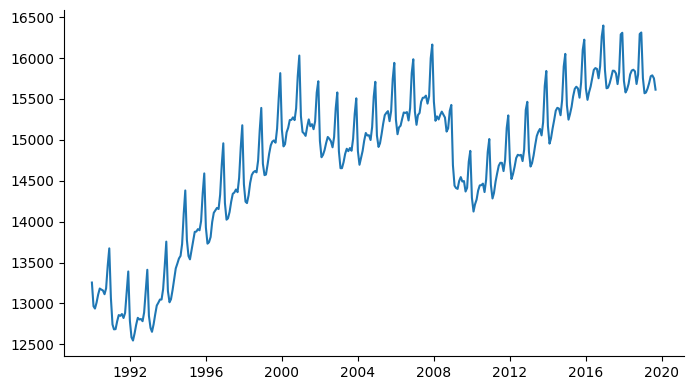

In [57]:
plt.plot(us_retail_employment.Employed)

In [58]:
stl = sm.tsa.STL(d.Employed).fit()

In [59]:
stl = sm.tsa.STL(d.Employed).fit()
s_stl = TSNaiveSeasonal(stl.seasonal, 12)

In [60]:
stl = sm.tsa.STL(d.Employed).fit()
s_stl = TSNaiveSeasonal(stl.seasonal, 12)
dr_stl = TSDrift(d.Employed - stl.seasonal)

In [61]:
from datetime import timedelta
end = us_retail_employment.index.max() + timedelta(days=365*4)

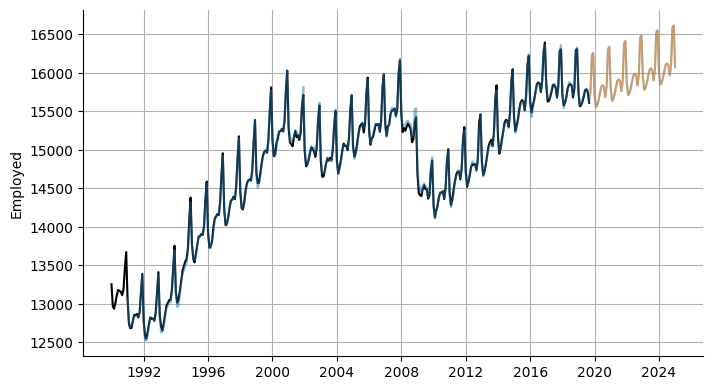

In [62]:
fig, ax = plt.subplots(figsize=sizets)
ax.plot(d.Employed, 'k')
end = pd.to_datetime('2025-01-01')
ax.plot(s_stl.predict(end=end) + dr_stl.predict(end=end), alpha=0.5)
ax.plot(s_stl.forecast(end=end) + dr_stl.forecast(end=end), alpha=0.5)
ax.set(ylabel='Employed')
ax.grid()

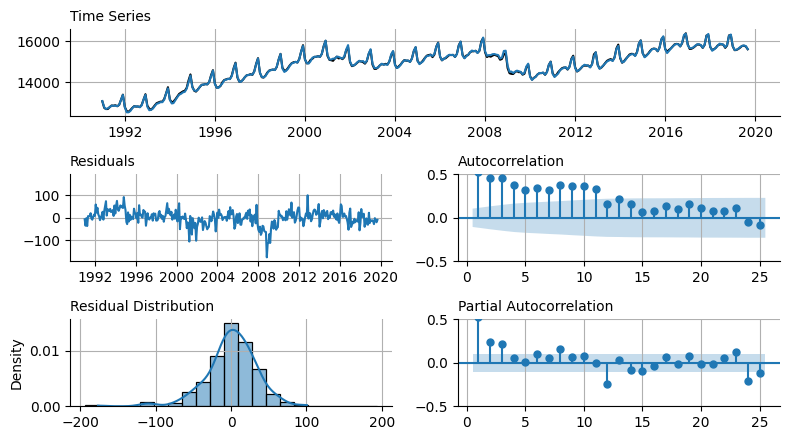

In [63]:
plot_tsresiduals(d.Employed, s_stl.predict() + dr_stl.predict());

## Evaluating forecast accuracy

In [64]:
aus_production['1995':]

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1995-01-01,1995 Q1,426,4714.0,430.0,1626,41768,131,1995-01-01,1995
1995-04-01,1995 Q2,408,3939.0,457.0,1703,43686,167,1995-04-01,1995
1995-07-01,1995 Q3,416,6137.0,417.0,1733,46022,181,1995-07-01,1995
1995-10-01,1995 Q4,520,4739.0,370.0,1545,42800,145,1995-10-01,1995
1996-01-01,1996 Q1,409,4275.0,310.0,1526,43661,133,1996-01-01,1996
...,...,...,...,...,...,...,...,...,...
2009-04-01,2009 Q2,398,NaN,NaN,2160,57471,238,2009-04-01,2009
2009-07-01,2009 Q3,419,NaN,NaN,2325,58394,252,2009-07-01,2009
2009-10-01,2009 Q4,488,NaN,NaN,2273,57336,210,2009-10-01,2009


In [65]:
aus_production[aus_production.index.quarter == 1]

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1956-01-01,1956 Q1,284,5225.0,189.0,465,3923,5,1956-01-01,1956
1957-01-01,1957 Q1,262,5577.0,187.0,529,4339,5,1957-01-01,1957
1958-01-01,1958 Q1,272,5758.0,199.0,554,4608,5,1958-01-01,1958
1959-01-01,1959 Q1,261,5478.0,208.0,573,4883,5,1959-01-01,1959
1960-01-01,1960 Q1,286,5980.0,242.0,621,5387,6,1960-01-01,1960
1961-01-01,1961 Q1,295,6022.0,241.0,688,5709,6,1961-01-01,1961
1962-01-01,1962 Q1,279,6072.0,229.0,637,6098,6,1962-01-01,1962
1963-01-01,1963 Q1,294,6051.0,231.0,674,6707,6,1963-01-01,1963
1964-01-01,1964 Q1,313,5890.0,293.0,797,7469,6,1964-01-01,1964


In [66]:
recent_production = aus_production['1992':]
split = '2007-12-01'
beer_train = recent_production[:split]
beer_test = recent_production[split:]

Ytrain = beer_train.Beer
ms = dict(
    Drift = TSDrift(Ytrain),
    Mean = TSMean(Ytrain),
    Naive = TSNaive(Ytrain),
    SeasonalNaive = TSNaiveSeasonal(Ytrain, 4),
)

In [67]:
beer_train

,Quarter,Beer,Tobacco,Bricks,Cement,Electricity,Gas,Date,Year
Date,,,,,,,,,
1992-01-01,1992 Q1,443,5777.0,383.0,1289,38332,117,1992-01-01,1992
1992-04-01,1992 Q2,410,5853.0,404.0,1501,39774,151,1992-04-01,1992
1992-07-01,1992 Q3,420,6416.0,446.0,1539,42246,175,1992-07-01,1992
1992-10-01,1992 Q4,532,5825.0,420.0,1568,38498,129,1992-10-01,1992
1993-01-01,1993 Q1,433,5724.0,394.0,1450,39460,116,1993-01-01,1993
...,...,...,...,...,...,...,...,...,...
2006-10-01,2006 Q4,491,NaN,NaN,2451,56249,192,2006-10-01,2006
2007-01-01,2007 Q1,427,NaN,NaN,2140,56244,187,2007-01-01,2007
2007-04-01,2007 Q2,383,NaN,NaN,2362,55036,234,2007-04-01,2007


In [68]:
stl = sm.tsa.STL(beer_train.Beer).fit()
s_stl = TSNaiveSeasonal(stl.seasonal, 12)
dr_stl = TSDrift(beer_train.Beer - stl.seasonal)

train_stl = s_stl.predict(end=end) + dr_stl.predict(end=end)
test_stl = s_stl.forecast(end=end) + dr_stl.forecast(end=end)


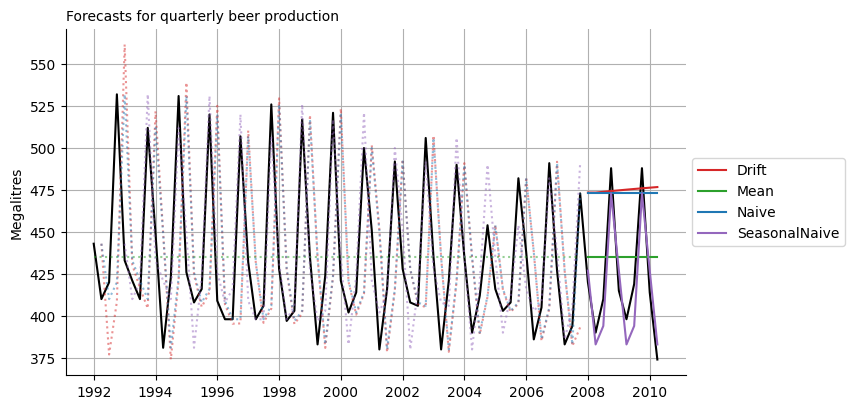

In [69]:
fig, ax = plt.subplots()
Y = recent_production.Beer
ax.plot(Y, color='k')
c = 'C3 C2 C0 C4'.split()
for ((label, model), c) in zip(ms.items(), c):
    ax.plot(model.predict(),  ls=':', color=c, alpha=.5)
    ax.plot(model.forecast(end=Y.index.max()),  color=c, label=label)
ax.set(ylabel='Megalitres')
ax.legend(loc='center left', bbox_to_anchor=[1, .5])
ax.set(title='Forecasts for quarterly beer production')
ax.grid()




In [70]:
def MAE(Y, y):
    """Mean absolute error."""
    return np.mean(np.abs(Y - y))


def MAPE(Y, y):
    """Mean absolute percent error."""
    return 100 * np.mean(np.abs((Y - y) / Y))

def RMSE(Y, y):
    """Root-mean-square error."""
    return np.sqrt(np.mean((Y - y) ** 2))



def tsaccuracy(Ytest, models):
    """Gather some metrics for a few models."""
    fs = RMSE, MAE, MAPE
    return pd.DataFrame({
        label: [f(Ytest, model.predict(Ytest.index.min(), Ytest.index.max()))
                for f in (RMSE, MAE, MAPE)]
        for (label, model) in models.items()
    }, index=[f.__name__ for f in fs]).T

In [71]:
stl_model_df = pd.DataFrame({'RMSE': RMSE(beer_test.Beer, test_stl), 'MAE': MAE(beer_test.Beer, test_stl), 'MAPE': MAPE(beer_test.Beer, test_stl)}, index=['stl_model'])

In [72]:
tsaccuracy(beer_test.Beer, ms)


,RMSE,MAE,MAPE
Drift,64.367670,58.524029,14.483635
Mean,38.447245,34.825000,8.283390
Naive,62.692902,57.400000,14.184424
SeasonalNaive,14.310835,13.400000,3.168503


In [73]:
df = pd.concat([_, stl_model_df])


In [74]:
df

,RMSE,MAE,MAPE
Drift,64.367670,58.524029,14.483635
Mean,38.447245,34.825000,8.283390
Naive,62.692902,57.400000,14.184424
SeasonalNaive,14.310835,13.400000,3.168503
stl_model,17.120801,13.525230,3.144569
